
# NB-05 · Masked Autoencoder (MAE) + DeepLabV3-ResNet50  
## Brain Tumour MRI Binary Semantic Segmentation from COCO Polygons

**Course:** CSE 438: Digital Image Processing  
**Course Instructor:** Dr Md Rifat Ahmmad Rashid  
**Department:** Department of Computer Science and Engineering  
**Institution:** East West University (EWU)

---

### Learning objective

This notebook investigates self-supervised masked-image reconstruction before supervised semantic segmentation:

1. **MAE pretraining:** randomly masked MRI regions are reconstructed using a ResNet-50 encoder and a lightweight reconstruction decoder.
2. **DeepLabV3 fine-tuning:** the same MAE-trained ResNet-50 encoder is copied directly into the DeepLabV3-ResNet50 backbone for binary tumour segmentation.

### Dataset convention

The dataset stores tumour boundaries in COCO polygon format. All polygons associated with one MRI are merged into a single semantic mask:

\[
0=\text{background}, \qquad 1=\text{tumour region}.
\]

### Architectural compatibility

A standard ViT-based MAE encoder cannot be copied directly into the ResNet-50 backbone of DeepLabV3. Therefore, this notebook implements **masked autoencoding with the ResNet-50 backbone required by DeepLabV3**, making the transfer methodologically valid.

### Computational safety

Standard contiguous tensors are used throughout. CUDA is selected only after an executable kernel test succeeds, and AMP is enabled only for a validated CUDA runtime. If the CUDA probe fails, the notebook automatically continues on CPU.



## Pipeline summary

\[
\text{unlabelled training MRI}
\longrightarrow
\text{patch masking}
\longrightarrow
\text{ResNet-50 encoder}
\longrightarrow
\text{reconstruction decoder}
\longrightarrow
\text{masked-region reconstruction loss}
\]

\[
\text{MAE-trained ResNet-50 encoder}
\longrightarrow
\text{DeepLabV3-ResNet50}
\longrightarrow
\text{tumour probability map}
\longrightarrow
\text{binary semantic mask}
\]

The MAE phase uses only MRI images. COCO polygon masks are first used during supervised DeepLabV3 fine-tuning and evaluation.


In [1]:

# ============================================================
# 1. Imports, reproducibility, configuration, and output paths
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import copy
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle
from PIL import Image, ImageDraw

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms as T
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.segmentation import deeplabv3_resnet50

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# Exact Kaggle path required for the course dataset.
# ------------------------------------------------------------
DATA_ROOT = Path("/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation")

# ------------------------------------------------------------
# All generated outputs remain under /kaggle/working/.
# ------------------------------------------------------------
OUTPUT_DIR = Path("/kaggle/working/mae_deeplabv3_brain_tumour")
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
METRIC_DIR = OUTPUT_DIR / "metrics"

for directory in [OUTPUT_DIR, FIGURE_DIR, CHECKPOINT_DIR, METRIC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Experiment configuration.
# ------------------------------------------------------------
SEED = 438
IMAGE_SIZE = 224
NUM_CLASSES = 2
NUM_WORKERS = 2

MAE_EPOCHS = 10
SEGMENTATION_EPOCHS = 10

MASK_PATCH_SIZE = 16
MASK_RATIO = 0.75
MAE_LR = 3e-4
SEGMENTATION_LR = 2e-4
WEIGHT_DECAY = 1e-4

# Set this to True only when the classroom experiment intentionally studies
# ImageNet initialisation followed by masked reconstruction.
USE_IMAGENET_INITIALISATION = False

def seed_everything(seed=SEED):
    """Make random masks, augmentations, and initial parameters reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        try:
            torch.cuda.manual_seed_all(seed)
        except Exception:
            pass

seed_everything()

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Dataset root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")


Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Dataset root: /kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation
Output directory: /kaggle/working/mae_deeplabv3_brain_tumour


In [2]:

# ============================================================
# 2. CUDA execution probe and AMP activation
# ============================================================

def select_safe_device():
    """
    Kaggle may expose a CUDA device whose kernels are incompatible with the
    current Torch build. Execute actual forward and backward operations before
    accepting CUDA or AMP for model training.
    """
    if not torch.cuda.is_available():
        print("CUDA is not available. CPU training selected; AMP is disabled.")
        return torch.device("cpu"), False

    try:
        probe_input = torch.randn(2, 3, 32, 32, device="cuda", requires_grad=True)
        probe_layer = nn.Conv2d(3, 8, kernel_size=3, padding=1).to("cuda")
        probe_loss = probe_layer(probe_input).square().mean()
        probe_loss.backward()
        torch.cuda.synchronize()

        print(f"CUDA kernel probe passed on: {torch.cuda.get_device_name(0)}")
        print("CUDA training selected; AMP is enabled for model forward passes.")
        return torch.device("cuda"), True
    except Exception as error:
        print("CUDA is visible, but the executable kernel probe failed.")
        print(f"Diagnostic: {type(error).__name__}: {error}")
        print("CPU fallback selected; AMP is disabled.")
        return torch.device("cpu"), False

DEVICE, AMP_ENABLED = select_safe_device()

def autocast_context():
    """Enable mixed precision only after successful CUDA kernel validation."""
    if not AMP_ENABLED:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=True)
    except AttributeError:
        return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)

def make_grad_scaler():
    """Retain compatibility with the AMP interfaces available in Kaggle images."""
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

MAE_BATCH_SIZE = 24 if DEVICE.type == "cuda" else 4
SEGMENTATION_BATCH_SIZE = 6 if DEVICE.type == "cuda" else 2
PIN_MEMORY = DEVICE.type == "cuda"

print(f"Selected device: {DEVICE}")
print(f"AMP enabled: {AMP_ENABLED}")
print(f"MAE batch size: {MAE_BATCH_SIZE}")
print(f"Segmentation batch size: {SEGMENTATION_BATCH_SIZE}")


CUDA kernel probe passed on: Tesla T4
CUDA training selected; AMP is enabled for model forward passes.
Selected device: cuda
AMP enabled: True
MAE batch size: 24
Segmentation batch size: 6



## COCO polygons and paired mask processing

Semantic segmentation needs one class label per pixel. Each COCO polygon is rasterised into a foreground mask, and all tumour polygons in the same MRI are merged. Nearest-neighbour interpolation is used for masks so that class labels remain discrete during geometric transformation.


In [3]:

# ============================================================
# 3. COCO parsing, binary-mask conversion, and datasets
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
NORMALISE = T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

def read_coco_records(split_directory: Path):
    """Read COCO image information and index polygon annotations by image id."""
    annotation_path = split_directory / "_annotations.coco.json"
    if not annotation_path.exists():
        raise FileNotFoundError(f"COCO annotation file not found: {annotation_path}")

    with open(annotation_path, "r", encoding="utf-8") as file:
        coco = json.load(file)

    annotations_by_image = {}
    for annotation in coco.get("annotations", []):
        annotations_by_image.setdefault(annotation["image_id"], []).append(annotation)

    records = []
    for information in coco.get("images", []):
        image_path = split_directory / information["file_name"]
        if not image_path.exists():
            fallback_path = split_directory / Path(information["file_name"]).name
            image_path = fallback_path if fallback_path.exists() else image_path

        if image_path.exists():
            records.append({
                "image_id": information["id"],
                "image_path": image_path,
                "file_name": information["file_name"],
                "annotations": annotations_by_image.get(information["id"], []),
            })

    if not records:
        raise RuntimeError(f"No readable images were indexed from {split_directory}.")
    return records

def polygons_to_binary_mask(image_size, annotations):
    """
    Merge all COCO polygon objects into one binary semantic mask:
      background = 0, tumour = 1.
    """
    mask = Image.new("L", image_size, color=0)
    drawer = ImageDraw.Draw(mask)

    for annotation in annotations:
        segmentation = annotation.get("segmentation", [])
        if not isinstance(segmentation, list):
            raise ValueError("This notebook expects polygon COCO annotations rather than RLE encoding.")

        for polygon in segmentation:
            if len(polygon) < 6:
                continue
            points = [
                (float(polygon[index]), float(polygon[index + 1]))
                for index in range(0, len(polygon) - 1, 2)
            ]
            drawer.polygon(points, outline=1, fill=1)

    return mask

class PairedSegmentationTransform:
    """Apply identical spatial transformation to MRI and binary target mask."""
    def __init__(self, training=False, size=IMAGE_SIZE):
        self.training = training
        self.size = size

    def __call__(self, image, mask):
        if self.training:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() < 0.20:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            rotation_angle = random.uniform(-10.0, 10.0)
            image = TF.rotate(
                image, rotation_angle,
                interpolation=InterpolationMode.BILINEAR, fill=0
            )
            mask = TF.rotate(
                mask, rotation_angle,
                interpolation=InterpolationMode.NEAREST, fill=0
            )

        image = TF.resize(image, [self.size, self.size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.size, self.size], interpolation=InterpolationMode.NEAREST)

        image_tensor = NORMALISE(TF.to_tensor(image)).contiguous()
        mask_array = np.asarray(mask, dtype=np.int64).copy()
        mask_tensor = torch.from_numpy((mask_array > 0).astype(np.int64)).long().contiguous()
        return image_tensor, mask_tensor

class COCOSemanticMaskDataset(Dataset):
    """Dataset for supervised DeepLabV3 fine-tuning and evaluation."""
    def __init__(self, split_directory, training=False):
        self.records = read_coco_records(Path(split_directory))
        self.transform = PairedSegmentationTransform(training=training)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record["image_path"]).convert("RGB")
        mask = polygons_to_binary_mask(image.size, record["annotations"])
        image_tensor, mask_tensor = self.transform(image, mask)
        return image_tensor, mask_tensor, record["file_name"]

MAE_IMAGE_AUGMENTATION = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.70, 1.0), interpolation=InterpolationMode.BILINEAR),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(brightness=0.12, contrast=0.12)], p=0.45),
    T.ToTensor(),
])

class MAEImageDataset(Dataset):
    """
    Self-supervised dataset. No annotation is accessed during MAE training.
    It returns the original image target in [0, 1] and its normalised counterpart.
    """
    def __init__(self, split_directory):
        self.records = read_coco_records(Path(split_directory))

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image = Image.open(self.records[index]["image_path"]).convert("RGB")
        target_rgb = MAE_IMAGE_AUGMENTATION(image).contiguous()
        normalised_input = NORMALISE(target_rgb.clone()).contiguous()
        return normalised_input, target_rgb


In [4]:

# ============================================================
# 4. Datasets, DataLoaders, and COCO-derived mask distribution
# ============================================================

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_ROOT}. Add the specified Kaggle dataset to the notebook."
    )

TRAIN_DIR = DATA_ROOT / "train"
VALID_DIR = DATA_ROOT / "valid"
TEST_DIR = DATA_ROOT / "test"

train_dataset = COCOSemanticMaskDataset(TRAIN_DIR, training=True)
train_display_dataset = COCOSemanticMaskDataset(TRAIN_DIR, training=False)
valid_dataset = COCOSemanticMaskDataset(VALID_DIR, training=False)
test_dataset = COCOSemanticMaskDataset(TEST_DIR, training=False)
mae_dataset = MAEImageDataset(TRAIN_DIR)

loader_options = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

train_loader = DataLoader(
    train_dataset, batch_size=SEGMENTATION_BATCH_SIZE,
    shuffle=True, drop_last=False, **loader_options
)
valid_loader = DataLoader(
    valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE,
    shuffle=False, drop_last=False, **loader_options
)
test_loader = DataLoader(
    test_dataset, batch_size=SEGMENTATION_BATCH_SIZE,
    shuffle=False, drop_last=False, **loader_options
)
feature_loader = DataLoader(
    valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE,
    shuffle=False, drop_last=False, **loader_options
)
mae_loader = DataLoader(
    mae_dataset, batch_size=MAE_BATCH_SIZE,
    shuffle=True, drop_last=False, **loader_options
)

print(f"Training images:   {len(train_dataset)}")
print(f"Validation images: {len(valid_dataset)}")
print(f"Test images:       {len(test_dataset)}")
print(f"MAE batches per epoch: {len(mae_loader)}")

def measure_foreground_distribution(dataset, split_name):
    tumour_pixels = 0
    tumour_images = 0
    total_pixels = 0

    for _, mask, _ in tqdm(dataset, desc=f"Inspecting {split_name} masks", leave=False):
        foreground = int(mask.sum().item())
        tumour_pixels += foreground
        tumour_images += int(foreground > 0)
        total_pixels += int(mask.numel())

    return {
        "split": split_name,
        "images": len(dataset),
        "images_with_tumour": tumour_images,
        "tumour_image_percentage": 100.0 * tumour_images / max(len(dataset), 1),
        "foreground_pixel_percentage": 100.0 * tumour_pixels / max(total_pixels, 1),
    }

mask_summary = pd.DataFrame([
    measure_foreground_distribution(train_display_dataset, "train"),
    measure_foreground_distribution(valid_dataset, "valid"),
    measure_foreground_distribution(test_dataset, "test"),
])
mask_summary.to_csv(METRIC_DIR / "mask_distribution.csv", index=False)
mask_summary


Training images:   1502
Validation images: 429
Test images:       215
MAE batches per epoch: 63


Inspecting train masks:   0%|          | 0/1502 [00:00<?, ?it/s]

Inspecting valid masks:   0%|          | 0/429 [00:00<?, ?it/s]

Inspecting test masks:   0%|          | 0/215 [00:00<?, ?it/s]

,split,images,images_with_tumour,tumour_image_percentage,foreground_pixel_percentage
0,train,1502,1501,99.933422,3.710254
1,valid,429,429,100.000000,3.721827
2,test,215,215,100.000000,3.716379


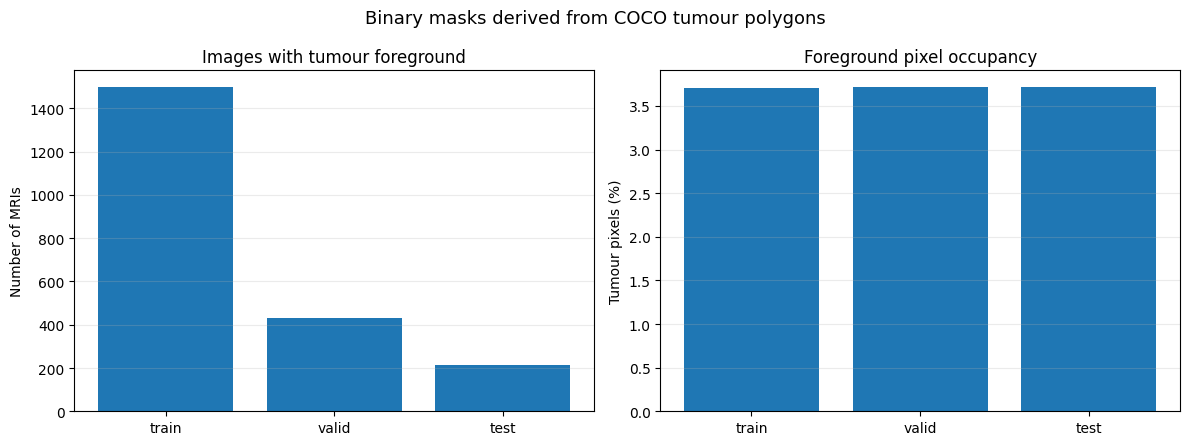

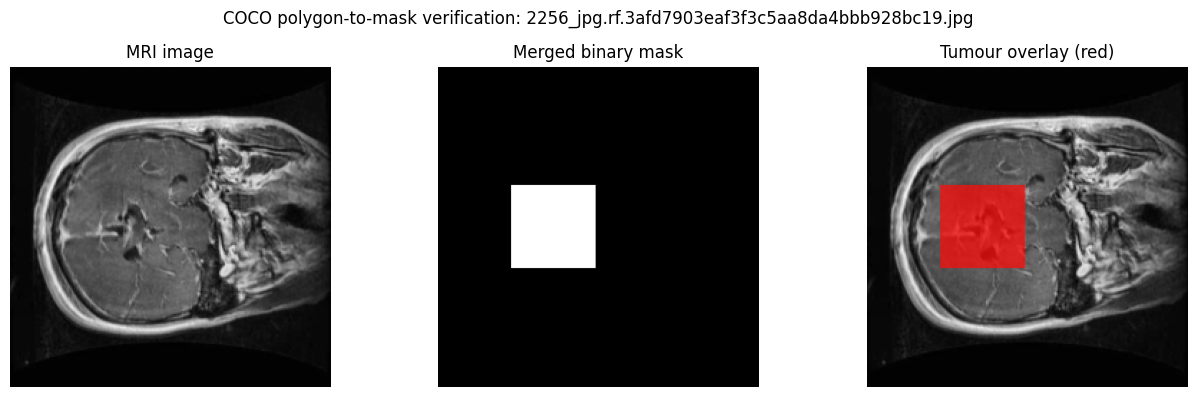

In [5]:

# ============================================================
# 5. Ground-truth mask visualisation with visible tumour overlay
# ============================================================

def undo_normalisation(image_tensor):
    """Convert a normalised tensor to a displayable RGB image."""
    mean = torch.tensor(IMAGENET_MEAN).reshape(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).reshape(3, 1, 1)
    restored = image_tensor.detach().cpu() * std + mean
    return restored.clamp(0, 1).permute(1, 2, 0).numpy()

def colour_mask_overlay(image_array, mask_array, colour=(1.0, 0.04, 0.04), alpha=0.74):
    """Blend a strong colour only inside the tumour region so small masks remain visible."""
    output = image_array.copy()
    region = np.asarray(mask_array).astype(bool)
    if region.any():
        colour_value = np.asarray(colour, dtype=np.float32)
        output[region] = (1.0 - alpha) * output[region] + alpha * colour_value
    return np.clip(output, 0.0, 1.0)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(mask_summary["split"], mask_summary["images_with_tumour"])
axes[0].set_title("Images with tumour foreground")
axes[0].set_ylabel("Number of MRIs")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(mask_summary["split"], mask_summary["foreground_pixel_percentage"])
axes[1].set_title("Foreground pixel occupancy")
axes[1].set_ylabel("Tumour pixels (%)")
axes[1].grid(axis="y", alpha=0.25)

figure.suptitle("Binary masks derived from COCO tumour polygons", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "01_mask_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

positive_index = next(
    (index for index in range(len(train_display_dataset))
     if train_display_dataset[index][1].sum().item() > 0),
    0
)

sample_image, sample_mask, sample_name = train_display_dataset[positive_index]
sample_rgb = undo_normalisation(sample_image)
sample_mask_array = sample_mask.numpy()
sample_overlay = colour_mask_overlay(sample_rgb, sample_mask_array)

figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(sample_rgb)
axes[0].set_title("MRI image")
axes[1].imshow(sample_mask_array, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Merged binary mask")
axes[2].imshow(sample_overlay)
axes[2].set_title("Tumour overlay (red)")
for axis in axes:
    axis.axis("off")

figure.suptitle(f"COCO polygon-to-mask verification: {sample_name}", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "02_mask_overlay.png", dpi=180, bbox_inches="tight")
plt.show()


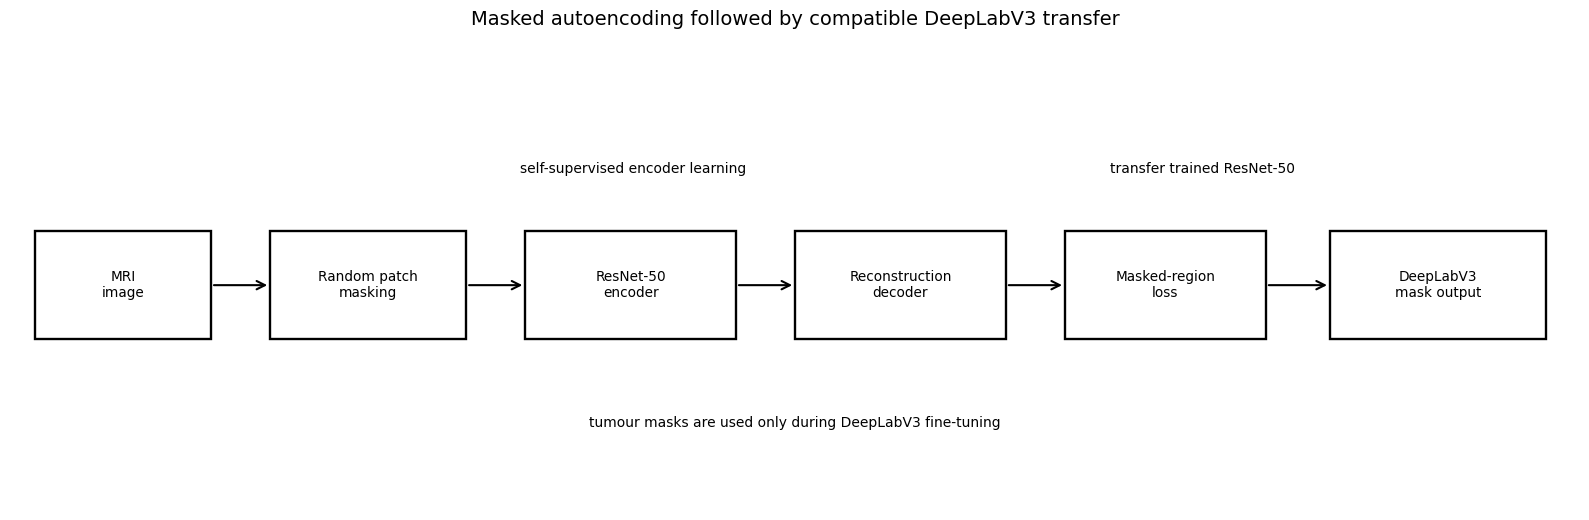

In [6]:

# ============================================================
# 6. Instructional workflow diagram: MAE representation learning to DeepLabV3
# ============================================================

figure, axis = plt.subplots(figsize=(16, 5.3))
axis.set_xlim(0, 16)
axis.set_ylim(0, 5.3)
axis.axis("off")

diagram_boxes = [
    (0.25, 1.9, 1.8, 1.2, "MRI\nimage"),
    (2.65, 1.9, 2.0, 1.2, "Random patch\nmasking"),
    (5.25, 1.9, 2.15, 1.2, "ResNet-50\nencoder"),
    (8.0, 1.9, 2.15, 1.2, "Reconstruction\ndecoder"),
    (10.75, 1.9, 2.05, 1.2, "Masked-region\nloss"),
    (13.45, 1.9, 2.2, 1.2, "DeepLabV3\nmask output"),
]
for x, y, width, height, label in diagram_boxes:
    axis.add_patch(Rectangle((x, y), width, height, fill=False, linewidth=1.7))
    axis.text(x + width / 2, y + height / 2, label, ha="center", va="center", fontsize=9.8)

for start, end in [
    ((2.05, 2.5), (2.65, 2.5)),
    ((4.65, 2.5), (5.25, 2.5)),
    ((7.4, 2.5), (8.0, 2.5)),
    ((10.15, 2.5), (10.75, 2.5)),
    ((12.8, 2.5), (13.45, 2.5)),
]:
    axis.add_patch(FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=15, linewidth=1.5))

axis.text(6.35, 3.75, "self-supervised encoder learning", ha="center", fontsize=10)
axis.text(12.15, 3.75, "transfer trained ResNet-50", ha="center", fontsize=10)
axis.text(8.0, 0.92, "tumour masks are used only during DeepLabV3 fine-tuning", ha="center", fontsize=10)

axis.set_title("Masked autoencoding followed by compatible DeepLabV3 transfer", fontsize=14)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "03_mae_deeplabv3_workflow.png", dpi=180, bbox_inches="tight")
plt.show()



## Masked autoencoder implementation

During self-supervised learning, a high proportion of square image regions is hidden. The encoder observes the corrupted MRI and the decoder predicts the original intensity values. The reconstruction loss is calculated **only on hidden pixels**, preventing the network from succeeding by copying unmasked content.

\[
\mathcal{L}_{\text{MAE}} =
\frac{1}{|\Omega_m|}
\sum_{p \in \Omega_m}
\left[
\lvert \hat{x}_p-x_p \rvert
+
0.2(\hat{x}_p-x_p)^2
\right],
\]

where \(\Omega_m\) denotes the masked pixel set.


In [7]:

# ============================================================
# 7. Patch masking and ResNet-50 masked-autoencoder architecture
# ============================================================

def build_resnet50_encoder(use_imagenet=False):
    """Construct the encoder later transferred into DeepLabV3-ResNet50."""
    if use_imagenet:
        try:
            encoder = resnet50(weights=ResNet50_Weights.DEFAULT)
            print("ResNet-50 encoder initialised from ImageNet weights.")
        except Exception as error:
            print(f"ImageNet weights unavailable ({error}); using random initialisation.")
            encoder = resnet50(weights=None)
    else:
        encoder = resnet50(weights=None)
    return encoder

def resnet_spatial_features(encoder, images):
    """Extract the final 7 x 7 ResNet convolutional representation."""
    x = encoder.conv1(images)
    x = encoder.bn1(x)
    x = encoder.relu(x)
    x = encoder.maxpool(x)
    x = encoder.layer1(x)
    x = encoder.layer2(x)
    x = encoder.layer3(x)
    x = encoder.layer4(x)
    return x

def resnet_pooled_features(encoder, images):
    """Obtain one feature vector per MRI for feature-space visualisation."""
    features = resnet_spatial_features(encoder, images)
    return F.adaptive_avg_pool2d(features, output_size=1).flatten(1)

def create_patch_mask(images, patch_size=MASK_PATCH_SIZE, mask_ratio=MASK_RATIO):
    """
    Construct a random binary pixel mask from a coarse patch grid.
    The mask is shared across RGB channels: 1 indicates hidden/reconstructed pixels.
    """
    batch_size, _, height, width = images.shape
    if height % patch_size != 0 or width % patch_size != 0:
        raise ValueError("IMAGE_SIZE must be divisible by MASK_PATCH_SIZE.")

    grid_height = height // patch_size
    grid_width = width // patch_size
    number_of_patches = grid_height * grid_width
    number_to_mask = max(1, int(round(number_of_patches * mask_ratio)))

    random_scores = torch.rand(batch_size, number_of_patches, device=images.device)
    masked_ids = random_scores.argsort(dim=1)[:, :number_to_mask]

    patch_mask = torch.zeros(batch_size, number_of_patches, device=images.device)
    patch_mask.scatter_(1, masked_ids, 1.0)
    patch_mask = patch_mask.view(batch_size, 1, grid_height, grid_width)
    pixel_mask = patch_mask.repeat_interleave(patch_size, dim=2).repeat_interleave(patch_size, dim=3)

    # Normalised value zero represents the ImageNet channel means and acts as
    # a neutral masked token for a CNN-based reconstruction encoder.
    masked_images = images * (1.0 - pixel_mask)
    return masked_images.contiguous(), pixel_mask.contiguous()

class ReconstructionDecoder(nn.Module):
    """Upsample ResNet-50 spatial features back to the 224 x 224 RGB image grid."""
    def __init__(self):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 512, kernel_size=2, stride=2),  # 7 -> 14
            nn.BatchNorm2d(512),
            nn.GELU(),
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),   # 14 -> 28
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),   # 28 -> 56
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),    # 56 -> 112
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.ConvTranspose2d(64, 3, kernel_size=2, stride=2),      # 112 -> 224
        )

    def forward(self, features):
        return torch.sigmoid(self.decoder(features))

class ResNetMaskedAutoencoder(nn.Module):
    """
    CNN-compatible MAE variant: a ResNet-50 encoder observes a patch-masked MRI
    and a reconstruction decoder predicts original intensity values.
    """
    def __init__(self, use_imagenet=False):
        super().__init__()
        self.encoder = build_resnet50_encoder(use_imagenet=use_imagenet)
        self.decoder = ReconstructionDecoder()

    def forward(self, masked_images):
        encoded_features = resnet_spatial_features(self.encoder, masked_images)
        return self.decoder(encoded_features)

def masked_reconstruction_loss(reconstruction, target, pixel_mask, epsilon=1e-6):
    """Calculate robust reconstruction error only over the hidden image regions."""
    expanded_mask = pixel_mask.expand_as(target).float()
    absolute_error = (reconstruction.float() - target.float()).abs()
    squared_error = (reconstruction.float() - target.float()).square()
    combined_error = absolute_error + 0.2 * squared_error
    return (combined_error * expanded_mask).sum() / (expanded_mask.sum() + epsilon)


In [8]:

# ============================================================
# 8. MAE backward smoke test and ten-epoch pretraining
# ============================================================

mae_model = ResNetMaskedAutoencoder(
    use_imagenet=USE_IMAGENET_INITIALISATION
).to(DEVICE)

# Preserve encoder state before MAE to compare representations afterwards.
initial_encoder_state = copy.deepcopy(mae_model.encoder.state_dict())
torch.save(initial_encoder_state, CHECKPOINT_DIR / "initial_resnet50_encoder.pth")

mae_optimizer = torch.optim.AdamW(
    mae_model.parameters(), lr=MAE_LR, weight_decay=WEIGHT_DECAY
)
mae_scaler = make_grad_scaler()

# ------------------------------------------------------------
# Smoke test: includes backward propagation before full training.
# ------------------------------------------------------------
smoke_input, smoke_target = next(iter(mae_loader))
smoke_input = smoke_input.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
smoke_target = smoke_target.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
smoke_masked, smoke_mask = create_patch_mask(smoke_input)

mae_optimizer.zero_grad(set_to_none=True)
with autocast_context():
    smoke_reconstruction = mae_model(smoke_masked)
    smoke_loss = masked_reconstruction_loss(smoke_reconstruction, smoke_target, smoke_mask)

assert smoke_reconstruction.shape == smoke_target.shape
assert torch.isfinite(smoke_loss).item(), "MAE smoke-test loss is not finite."
mae_scaler.scale(smoke_loss).backward()
mae_optimizer.zero_grad(set_to_none=True)

print(f"MAE forward/backward smoke test passed. Reconstruction loss: {smoke_loss.item():.4f}")

# ------------------------------------------------------------
# Ten training epochs.
# ------------------------------------------------------------
mae_history = []

for epoch in range(1, MAE_EPOCHS + 1):
    mae_model.train()
    epoch_losses = []

    progress = tqdm(mae_loader, desc=f"MAE epoch {epoch:02d}/{MAE_EPOCHS}", leave=True)
    for normalised_images, target_images in progress:
        normalised_images = normalised_images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        target_images = target_images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        masked_images, pixel_mask = create_patch_mask(normalised_images)

        mae_optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            reconstruction = mae_model(masked_images)
            loss = masked_reconstruction_loss(reconstruction, target_images, pixel_mask)

        mae_scaler.scale(loss).backward()
        mae_scaler.step(mae_optimizer)
        mae_scaler.update()

        epoch_losses.append(float(loss.detach().cpu()))
        progress.set_postfix(masked_loss=f"{np.mean(epoch_losses):.4f}")

    mae_history.append({
        "epoch": epoch,
        "masked_reconstruction_loss": float(np.mean(epoch_losses)),
    })

mae_history_df = pd.DataFrame(mae_history)
mae_history_df.to_csv(METRIC_DIR / "mae_pretraining_history.csv", index=False)

torch.save(
    {
        "encoder_state_dict": mae_model.encoder.state_dict(),
        "decoder_state_dict": mae_model.decoder.state_dict(),
        "mask_patch_size": MASK_PATCH_SIZE,
        "mask_ratio": MASK_RATIO,
        "epochs": MAE_EPOCHS,
    },
    CHECKPOINT_DIR / "mae_resnet50_encoder_decoder.pth",
)

mae_history_df


MAE forward/backward smoke test passed. Reconstruction loss: 0.3123


MAE epoch 01/10:   0%|          | 0/63 [00:00<?, ?it/s]

MAE epoch 02/10:   0%|          | 0/63 [00:00<?, ?it/s]

MAE epoch 03/10:   0%|          | 0/63 [00:00<?, ?it/s]

MAE epoch 04/10:   0%|          | 0/63 [00:00<?, ?it/s]

...

MAE epoch 07/10:   0%|          | 0/63 [00:00<?, ?it/s]

MAE epoch 08/10:   0%|          | 0/63 [00:00<?, ?it/s]

MAE epoch 09/10:   0%|          | 0/63 [00:00<?, ?it/s]

MAE epoch 10/10:   0%|          | 0/63 [00:00<?, ?it/s]

,epoch,masked_reconstruction_loss
0,1,0.194280
1,2,0.121876
2,3,0.108637
3,4,0.102679
4,5,0.099654
5,6,0.096745
6,7,0.093526
7,8,0.092093
8,9,0.090672
9,10,0.089416


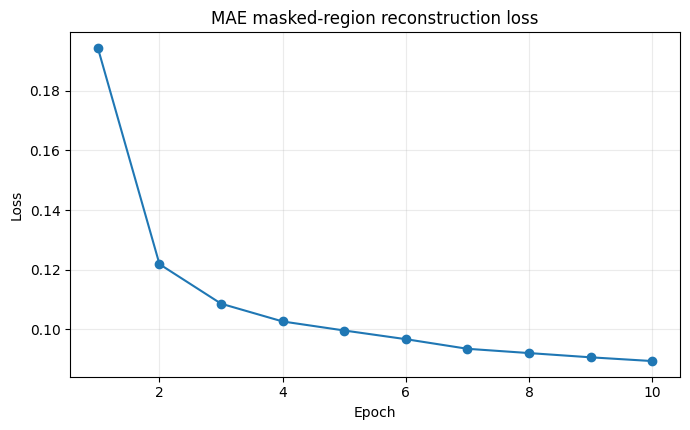

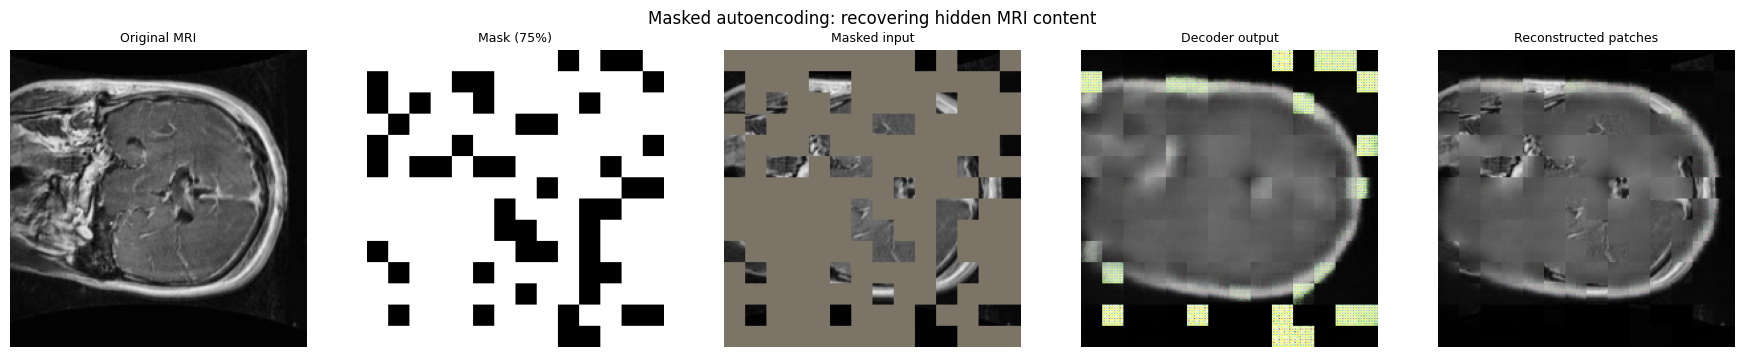

In [9]:

# ============================================================
# 9. MAE reconstruction visualisation and pretraining curve
# ============================================================

mae_model.eval()
visual_normalised, visual_target = mae_dataset[positive_index]
visual_normalised = visual_normalised.unsqueeze(0).to(DEVICE).contiguous()
visual_target = visual_target.unsqueeze(0).to(DEVICE).contiguous()

with torch.inference_mode():
    masked_input, displayed_mask = create_patch_mask(visual_normalised)
    with autocast_context():
        reconstructed = mae_model(masked_input)

target_display = visual_target[0].cpu().permute(1, 2, 0).numpy()
masked_display = undo_normalisation(masked_input[0])
reconstruction_display = reconstructed[0].float().cpu().permute(1, 2, 0).clamp(0, 1).numpy()
mask_display = displayed_mask[0, 0].cpu().numpy()

# Insert reconstructed values only inside hidden patches for a completion view.
completed_display = target_display * (1.0 - mask_display[..., None]) + reconstruction_display * mask_display[..., None]

figure, axis = plt.subplots(figsize=(7, 4.4))
axis.plot(mae_history_df["epoch"], mae_history_df["masked_reconstruction_loss"], marker="o")
axis.set_title("MAE masked-region reconstruction loss")
axis.set_xlabel("Epoch")
axis.set_ylabel("Loss")
axis.grid(alpha=0.25)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "04_mae_training_curve.png", dpi=180, bbox_inches="tight")
plt.show()

figure, axes = plt.subplots(1, 5, figsize=(18, 3.6))
panels = [
    (target_display, "Original MRI", None),
    (mask_display, f"Mask ({MASK_RATIO:.0%})", "gray"),
    (masked_display, "Masked input", None),
    (reconstruction_display, "Decoder output", None),
    (completed_display, "Reconstructed patches", None),
]
for axis, (panel, title, colour_map) in zip(axes, panels):
    if colour_map is None:
        axis.imshow(panel)
    else:
        axis.imshow(panel, cmap=colour_map, vmin=0, vmax=1)
    axis.set_title(title, fontsize=9)
    axis.axis("off")

figure.suptitle("Masked autoencoding: recovering hidden MRI content", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "05_mae_reconstruction_example.png", dpi=180, bbox_inches="tight")
plt.show()



## Transfer to DeepLabV3-ResNet50

DeepLabV3 uses a ResNet-50 backbone and atrous spatial pyramid pooling for multi-scale context. Because the MAE encoder was implemented using the same ResNet-50 backbone, all matching convolutional and normalisation parameters can be directly copied before segmentation fine-tuning.


In [10]:

# ============================================================
# 10. DeepLabV3 construction, compatible MAE transfer, and segmentation loss
# ============================================================

def build_deeplab_from_mae(trained_mae_model):
    """Transfer shape-compatible MAE ResNet-50 encoder tensors into DeepLabV3."""
    model = deeplabv3_resnet50(
        weights=None,
        weights_backbone=None,
        num_classes=NUM_CLASSES,
        aux_loss=True,
    )

    mae_encoder_state = trained_mae_model.encoder.state_dict()
    deeplab_backbone_state = model.backbone.state_dict()

    transferable = {
        key: value.detach().cpu()
        for key, value in mae_encoder_state.items()
        if key in deeplab_backbone_state
        and deeplab_backbone_state[key].shape == value.shape
    }

    missing_keys, unexpected_keys = model.backbone.load_state_dict(transferable, strict=False)

    print(f"Transferred MAE encoder tensors into DeepLabV3: {len(transferable)}")
    print(f"DeepLab backbone entries not loaded from MAE: {len(missing_keys)}")
    print(f"Unexpected entries during transfer: {len(unexpected_keys)}")
    return model

segmentation_model = build_deeplab_from_mae(mae_model).to(DEVICE)

class CrossEntropyForegroundDiceLoss(nn.Module):
    """Combine classwise cross-entropy with a foreground-sensitive Dice objective."""
    def __init__(self, dice_weight=1.0, epsilon=1e-6):
        super().__init__()
        self.dice_weight = dice_weight
        self.epsilon = epsilon

    def forward(self, logits, targets):
        cross_entropy = F.cross_entropy(logits, targets)

        foreground_probability = torch.softmax(logits.float(), dim=1)[:, 1]
        foreground_target = (targets == 1).float()

        intersection = (foreground_probability * foreground_target).sum(dim=(1, 2))
        denominator = foreground_probability.sum(dim=(1, 2)) + foreground_target.sum(dim=(1, 2))
        foreground_dice = (2.0 * intersection + self.epsilon) / (denominator + self.epsilon)
        dice_loss = 1.0 - foreground_dice.mean()

        return cross_entropy + self.dice_weight * dice_loss, cross_entropy.detach(), dice_loss.detach()

criterion = CrossEntropyForegroundDiceLoss()
segmentation_optimizer = torch.optim.AdamW(
    segmentation_model.parameters(),
    lr=SEGMENTATION_LR,
    weight_decay=WEIGHT_DECAY,
)
segmentation_scaler = make_grad_scaler()

def metric_counts(predictions, targets):
    """Accumulate foreground confusion counts and overall pixel agreement."""
    predictions = predictions == 1
    targets = targets == 1

    true_positive = int((predictions & targets).sum().item())
    false_positive = int((predictions & ~targets).sum().item())
    false_negative = int((~predictions & targets).sum().item())
    correct = int((predictions == targets).sum().item())
    total = int(targets.numel())
    return true_positive, false_positive, false_negative, correct, total

def calculate_metrics(tp, fp, fn, correct, total, epsilon=1e-7):
    return {
        "dice": (2.0 * tp + epsilon) / (2.0 * tp + fp + fn + epsilon),
        "iou": (tp + epsilon) / (tp + fp + fn + epsilon),
        "pixel_accuracy": correct / max(total, 1),
    }

def run_segmentation_epoch(model, loader, optimizer=None, scaler=None, description="evaluation"):
    training = optimizer is not None
    model.train(training)

    losses = []
    true_positive = false_positive = false_negative = correct = total = 0

    progress = tqdm(loader, desc=description, leave=False)
    for images, masks, _ in progress:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        masks = masks.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with autocast_context():
                outputs = model(images)
                logits = F.interpolate(
                    outputs["out"],
                    size=masks.shape[-2:],
                    mode="bilinear",
                    align_corners=False,
                )
                main_loss, _, _ = criterion(logits, masks)

                if training and "aux" in outputs:
                    auxiliary_logits = F.interpolate(
                        outputs["aux"],
                        size=masks.shape[-2:],
                        mode="bilinear",
                        align_corners=False,
                    )
                    auxiliary_loss, _, _ = criterion(auxiliary_logits, masks)
                    loss = main_loss + 0.4 * auxiliary_loss
                else:
                    loss = main_loss

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        losses.append(float(loss.detach().cpu()))
        predictions = logits.detach().argmax(dim=1)
        batch_counts = metric_counts(predictions, masks.detach())
        true_positive += batch_counts[0]
        false_positive += batch_counts[1]
        false_negative += batch_counts[2]
        correct += batch_counts[3]
        total += batch_counts[4]

        progress.set_postfix(loss=f"{np.mean(losses):.4f}")

    metrics = calculate_metrics(
        true_positive, false_positive, false_negative, correct, total
    )
    metrics["loss"] = float(np.mean(losses))
    return metrics


Transferred MAE encoder tensors into DeepLabV3: 318
DeepLab backbone entries not loaded from MAE: 0
Unexpected entries during transfer: 0


In [11]:

# ============================================================
# 11. Ten-epoch DeepLabV3 fine-tuning and held-out evaluation
# ============================================================

segmentation_history = []
best_validation_dice = -1.0
best_checkpoint_path = CHECKPOINT_DIR / "best_mae_deeplabv3_binary_segmentation.pth"

for epoch in range(1, SEGMENTATION_EPOCHS + 1):
    training_metrics = run_segmentation_epoch(
        segmentation_model,
        train_loader,
        optimizer=segmentation_optimizer,
        scaler=segmentation_scaler,
        description=f"DeepLabV3 train {epoch:02d}/{SEGMENTATION_EPOCHS}",
    )
    validation_metrics = run_segmentation_epoch(
        segmentation_model,
        valid_loader,
        description=f"DeepLabV3 valid {epoch:02d}/{SEGMENTATION_EPOCHS}",
    )

    record = {"epoch": epoch}
    for name, value in training_metrics.items():
        record[f"train_{name}"] = value
    for name, value in validation_metrics.items():
        record[f"valid_{name}"] = value
    segmentation_history.append(record)

    print(
        f"Epoch {epoch:02d}: "
        f"train loss={training_metrics['loss']:.4f}, train Dice={training_metrics['dice']:.4f} | "
        f"valid loss={validation_metrics['loss']:.4f}, valid Dice={validation_metrics['dice']:.4f}, "
        f"valid IoU={validation_metrics['iou']:.4f}, "
        f"valid accuracy={validation_metrics['pixel_accuracy']:.4f}"
    )

    if validation_metrics["dice"] > best_validation_dice:
        best_validation_dice = validation_metrics["dice"]
        torch.save(
            {
                "model_state_dict": segmentation_model.state_dict(),
                "epoch": epoch,
                "validation_metrics": validation_metrics,
                "encoder_source": "ResNet-50 masked-autoencoder encoder",
            },
            best_checkpoint_path,
        )

segmentation_history_df = pd.DataFrame(segmentation_history)
segmentation_history_df.to_csv(METRIC_DIR / "deeplabv3_training_history.csv", index=False)

best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
segmentation_model.load_state_dict(best_checkpoint["model_state_dict"])

test_metrics = run_segmentation_epoch(
    segmentation_model, test_loader, description="Held-out test evaluation"
)
test_metrics_df = pd.DataFrame([test_metrics])
test_metrics_df.to_csv(METRIC_DIR / "test_metrics.csv", index=False)

print("\nHeld-out test performance from the best validation checkpoint")
print(test_metrics_df.round(4).to_string(index=False))
print(f"\nBest checkpoint saved at: {best_checkpoint_path}")


DeepLabV3 train 01/10:   0%|          | 0/251 [00:00<?, ?it/s]

DeepLabV3 valid 01/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 01: train loss=1.0965, train Dice=0.4455 | valid loss=0.6126, valid Dice=0.5568, valid IoU=0.3858, valid accuracy=0.9663


DeepLabV3 train 02/10:   0%|          | 0/251 [00:00<?, ?it/s]

DeepLabV3 valid 02/10:   0%|          | 0/72 [00:00<?, ?it/s]

...

DeepLabV3 train 10/10:   0%|          | 0/251 [00:00<?, ?it/s]

DeepLabV3 valid 10/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 10: train loss=0.4751, train Dice=0.7406 | valid loss=0.3691, valid Dice=0.7229, valid IoU=0.5660, valid accuracy=0.9797


Held-out test evaluation:   0%|          | 0/36 [00:00<?, ?it/s]


Held-out test performance from the best validation checkpoint
  dice    iou  pixel_accuracy   loss
0.7257 0.5694          0.9786 0.3652

Best checkpoint saved at: /kaggle/working/mae_deeplabv3_brain_tumour/checkpoints/best_mae_deeplabv3_binary_segmentation.pth


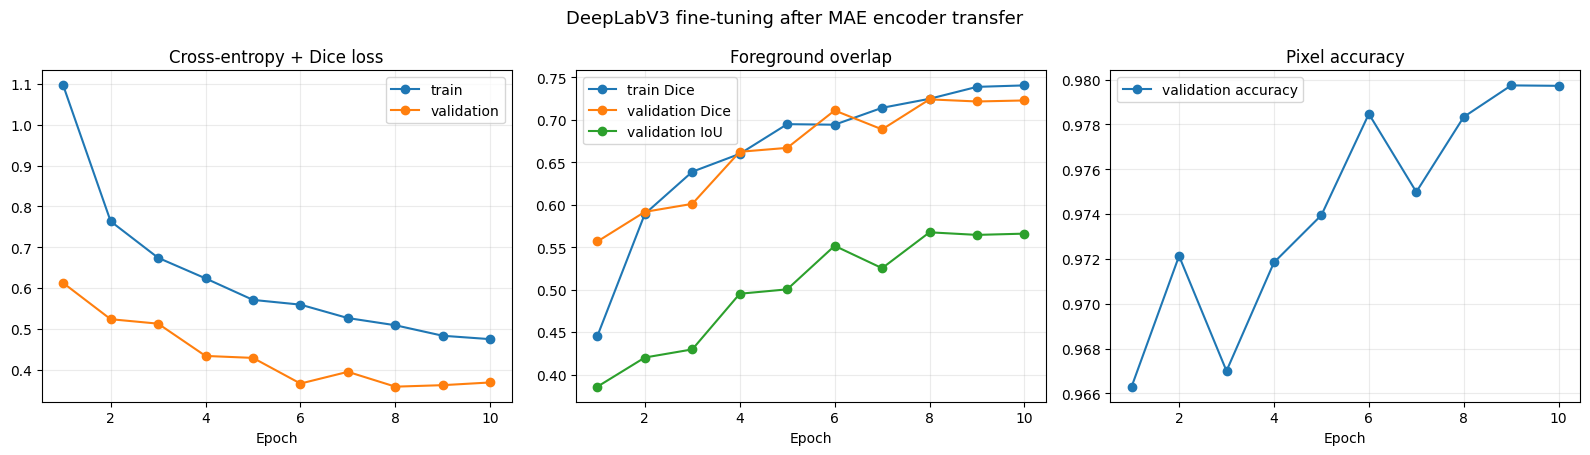

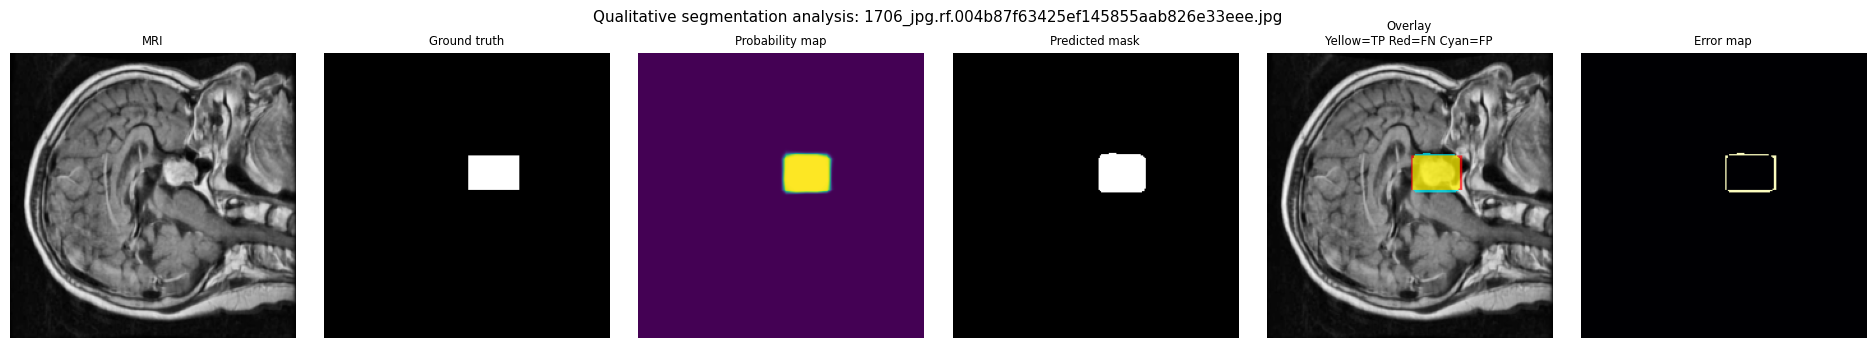

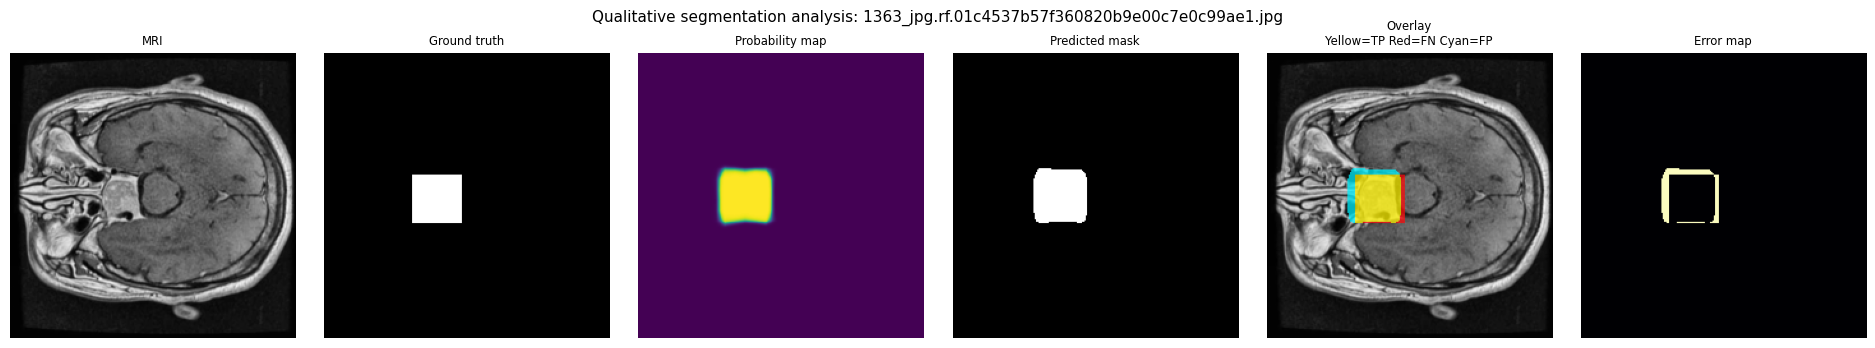

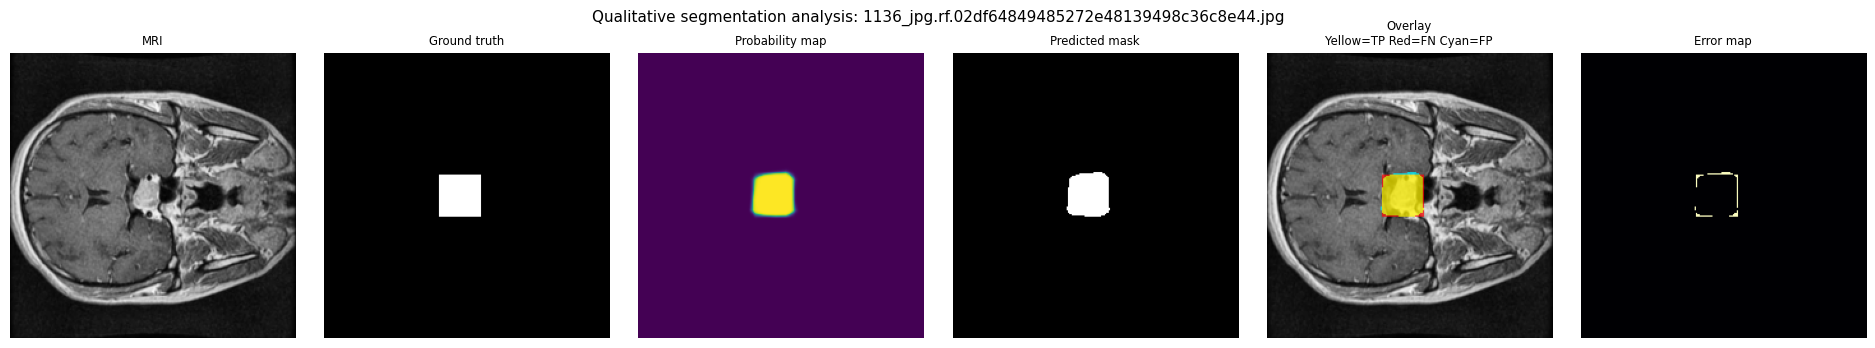

In [12]:

# ============================================================
# 12. Segmentation curves and visible error-coded overlays
# ============================================================

figure, axes = plt.subplots(1, 3, figsize=(16, 4.6))

axes[0].plot(segmentation_history_df["epoch"], segmentation_history_df["train_loss"], marker="o", label="train")
axes[0].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_loss"], marker="o", label="validation")
axes[0].set_title("Cross-entropy + Dice loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["train_dice"], marker="o", label="train Dice")
axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_dice"], marker="o", label="validation Dice")
axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_iou"], marker="o", label="validation IoU")
axes[1].set_title("Foreground overlap")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].plot(
    segmentation_history_df["epoch"], segmentation_history_df["valid_pixel_accuracy"],
    marker="o", label="validation accuracy"
)
axes[2].set_title("Pixel accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.25)

figure.suptitle("DeepLabV3 fine-tuning after MAE encoder transfer", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "06_segmentation_training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

@torch.inference_mode()
def predict_one_sample(model, dataset, index):
    image, ground_truth, file_name = dataset[index]
    input_batch = image.unsqueeze(0).to(DEVICE).contiguous()

    with autocast_context():
        logits = model(input_batch)["out"]
        logits = F.interpolate(
            logits, size=ground_truth.shape[-2:],
            mode="bilinear", align_corners=False
        )

    probability = torch.softmax(logits.float(), dim=1)[0, 1].cpu()
    prediction = (probability >= 0.5).long()
    return image, ground_truth, probability, prediction, file_name

def comparison_overlay(image_array, ground_truth_array, prediction_array, alpha=0.74):
    """
    Visualise segmentation evidence:
       yellow = correctly predicted tumour foreground,
       red    = missed tumour region,
       cyan   = predicted foreground outside the annotation.
    """
    overlay = image_array.copy()
    truth = np.asarray(ground_truth_array).astype(bool)
    prediction = np.asarray(prediction_array).astype(bool)

    true_positive = truth & prediction
    false_negative = truth & ~prediction
    false_positive = prediction & ~truth

    for region, colour in [
        (false_negative, np.array([1.0, 0.04, 0.04], dtype=np.float32)),
        (false_positive, np.array([0.0, 0.95, 1.0], dtype=np.float32)),
        (true_positive, np.array([1.0, 0.95, 0.0], dtype=np.float32)),
    ]:
        if region.any():
            overlay[region] = (1.0 - alpha) * overlay[region] + alpha * colour

    return np.clip(overlay, 0.0, 1.0)

positive_test_indices = [
    index for index in range(len(test_dataset))
    if test_dataset[index][1].sum().item() > 0
][:3]
if not positive_test_indices:
    positive_test_indices = list(range(min(3, len(test_dataset))))

for example_number, index in enumerate(positive_test_indices, start=1):
    image, ground_truth, probability, prediction, file_name = predict_one_sample(
        segmentation_model, test_dataset, index
    )

    image_array = undo_normalisation(image)
    ground_truth_array = ground_truth.numpy()
    probability_array = probability.numpy()
    prediction_array = prediction.numpy()
    overlay_array = comparison_overlay(image_array, ground_truth_array, prediction_array)
    error_array = (prediction != ground_truth).numpy().astype(np.float32)

    figure, axes = plt.subplots(1, 6, figsize=(19, 3.5))
    panels = [
        (image_array, "MRI", None),
        (ground_truth_array, "Ground truth", "gray"),
        (probability_array, "Probability map", "viridis"),
        (prediction_array, "Predicted mask", "gray"),
        (overlay_array, "Overlay\nYellow=TP Red=FN Cyan=FP", None),
        (error_array, "Error map", "magma"),
    ]

    for axis, (panel, title, colour_map) in zip(axes, panels):
        if colour_map is None:
            axis.imshow(panel)
        else:
            axis.imshow(panel, cmap=colour_map, vmin=0, vmax=1)
        axis.set_title(title, fontsize=8.4)
        axis.axis("off")

    figure.suptitle(f"Qualitative segmentation analysis: {file_name}", fontsize=11)
    figure.tight_layout()
    figure.savefig(
        FIGURE_DIR / f"07_prediction_example_{example_number}.png",
        dpi=180, bbox_inches="tight"
    )
    plt.show()



## Feature-space and spatial-response analysis

Three encoder states are compared:

1. **Initial ResNet-50:** before masked reconstruction learning.
2. **After MAE:** after learning to infer hidden MRI regions.
3. **After DeepLabV3 fine-tuning:** after learning tumour-mask supervision.

The t-SNE display illustrates local feature-neighbourhood behaviour. The response maps show the spatial distribution of final encoder activations and should be interpreted alongside segmentation masks and error maps.


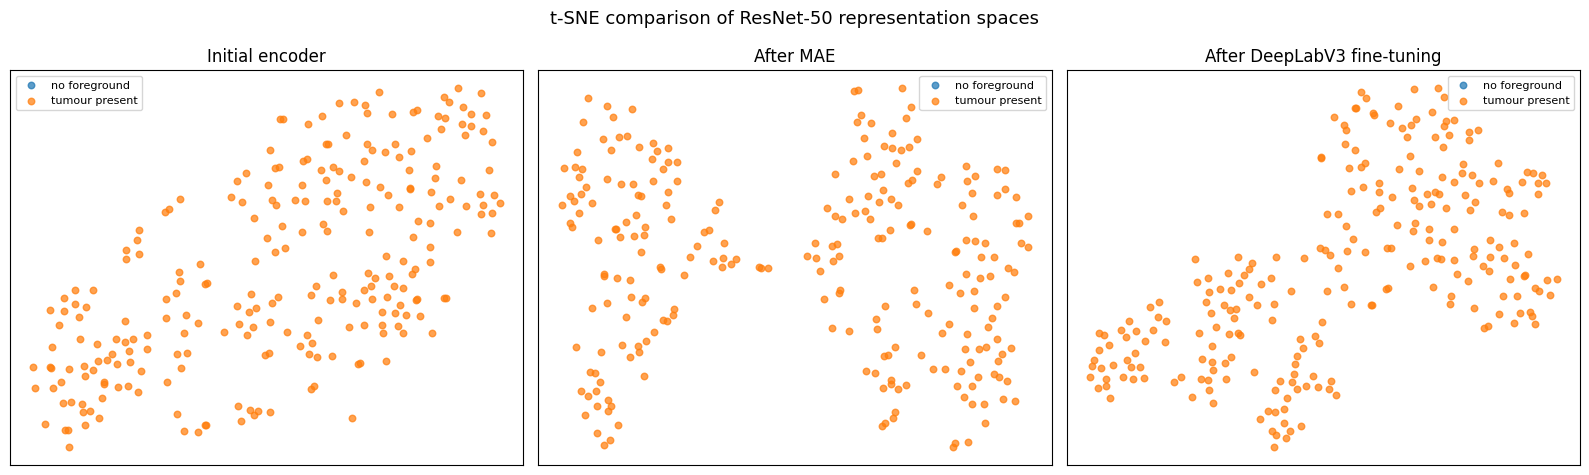

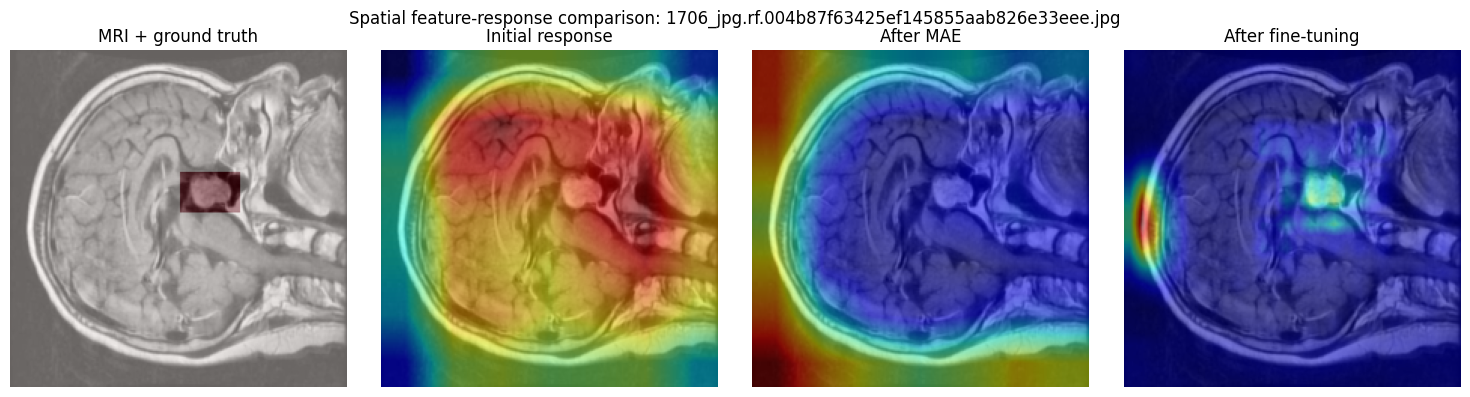

In [13]:

# ============================================================
# 13. Spatial feature responses and t-SNE comparison
# ============================================================

initial_encoder = build_resnet50_encoder(use_imagenet=False).to(DEVICE)
initial_encoder.load_state_dict(initial_encoder_state)
initial_encoder.eval()

mae_encoder = copy.deepcopy(mae_model.encoder).to(DEVICE)
mae_encoder.eval()

segmentation_model.eval()

@torch.inference_mode()
def collect_resnet_features(encoder, loader, maximum_samples=250):
    features = []
    labels = []

    for images, masks, _ in loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        vectors = resnet_pooled_features(encoder, images).float().cpu().numpy()
        tumour_present = (masks.flatten(1).sum(dim=1) > 0).long().numpy()

        features.append(vectors)
        labels.append(tumour_present)

        if sum(array.shape[0] for array in labels) >= maximum_samples:
            break

    return (
        np.concatenate(features, axis=0)[:maximum_samples],
        np.concatenate(labels, axis=0)[:maximum_samples],
    )

@torch.inference_mode()
def collect_deeplab_features(model, loader, maximum_samples=250):
    features = []
    labels = []

    for images, masks, _ in loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        spatial_features = model.backbone(images)["out"]
        vectors = F.adaptive_avg_pool2d(spatial_features.float(), output_size=1).flatten(1).cpu().numpy()
        tumour_present = (masks.flatten(1).sum(dim=1) > 0).long().numpy()

        features.append(vectors)
        labels.append(tumour_present)

        if sum(array.shape[0] for array in labels) >= maximum_samples:
            break

    return (
        np.concatenate(features, axis=0)[:maximum_samples],
        np.concatenate(labels, axis=0)[:maximum_samples],
    )

initial_features, feature_labels = collect_resnet_features(initial_encoder, feature_loader)
mae_features, _ = collect_resnet_features(mae_encoder, feature_loader)
finetuned_features, _ = collect_deeplab_features(segmentation_model, feature_loader)

def compute_tsne(features):
    standardised = StandardScaler().fit_transform(features)
    sample_count = standardised.shape[0]
    perplexity = max(2, min(30, sample_count // 4, sample_count - 1))
    return TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=SEED,
    ).fit_transform(standardised)

embedded_stages = [
    compute_tsne(initial_features),
    compute_tsne(mae_features),
    compute_tsne(finetuned_features),
]
stage_titles = [
    "Initial encoder",
    "After MAE",
    "After DeepLabV3 fine-tuning",
]

figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for axis, embedding, title in zip(axes, embedded_stages, stage_titles):
    for label_value, label_name in [(0, "no foreground"), (1, "tumour present")]:
        selected = feature_labels == label_value
        axis.scatter(
            embedding[selected, 0], embedding[selected, 1],
            s=22, alpha=0.72, label=label_name
        )
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.legend(fontsize=8)

figure.suptitle("t-SNE comparison of ResNet-50 representation spaces", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "08_tsne_three_stages.png", dpi=180, bbox_inches="tight")
plt.show()

response_index = positive_test_indices[0] if positive_test_indices else 0
response_image, response_mask, response_name = test_dataset[response_index]
response_batch = response_image.unsqueeze(0).to(DEVICE).contiguous()

@torch.inference_mode()
def spatial_response_from_encoder(encoder, input_batch, target_size):
    response = resnet_spatial_features(encoder, input_batch).float().abs().mean(dim=1, keepdim=True)
    response = F.interpolate(response, size=target_size, mode="bilinear", align_corners=False)[0, 0]
    response = response - response.min()
    response = response / (response.max() + 1e-7)
    return response.cpu().numpy()

@torch.inference_mode()
def spatial_response_from_deeplab(model, input_batch, target_size):
    response = model.backbone(input_batch)["out"].float().abs().mean(dim=1, keepdim=True)
    response = F.interpolate(response, size=target_size, mode="bilinear", align_corners=False)[0, 0]
    response = response - response.min()
    response = response / (response.max() + 1e-7)
    return response.cpu().numpy()

initial_map = spatial_response_from_encoder(initial_encoder, response_batch, response_mask.shape[-2:])
mae_map = spatial_response_from_encoder(mae_encoder, response_batch, response_mask.shape[-2:])
finetuned_map = spatial_response_from_deeplab(segmentation_model, response_batch, response_mask.shape[-2:])

base_image = undo_normalisation(response_image)
figure, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(base_image)
axes[0].imshow(response_mask.numpy(), cmap="Reds", alpha=0.40, vmin=0, vmax=1)
axes[0].set_title("MRI + ground truth")

for axis, activation, title in zip(
    axes[1:],
    [initial_map, mae_map, finetuned_map],
    ["Initial response", "After MAE", "After fine-tuning"],
):
    axis.imshow(base_image)
    axis.imshow(activation, cmap="jet", alpha=0.50, vmin=0, vmax=1)
    axis.set_title(title)

for axis in axes:
    axis.axis("off")

figure.suptitle(f"Spatial feature-response comparison: {response_name}", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "09_spatial_responses.png", dpi=180, bbox_inches="tight")
plt.show()


In [14]:

# ============================================================
# 14. Export experiment summary for classroom reporting
# ============================================================

experiment_summary = {
    "course": "CSE 438: Digital Image Processing",
    "instructor": "Dr Md Rifat Ahmmad Rashid",
    "pipeline": "ResNet-50 masked-autoencoder pretraining followed by DeepLabV3-ResNet50 segmentation",
    "dataset_root": str(DATA_ROOT),
    "classes": {"0": "background", "1": "tumour region"},
    "device": str(DEVICE),
    "amp_enabled": bool(AMP_ENABLED),
    "mae_epochs": MAE_EPOCHS,
    "segmentation_epochs": SEGMENTATION_EPOCHS,
    "mae_configuration": {
        "mask_patch_size": MASK_PATCH_SIZE,
        "mask_ratio": MASK_RATIO,
        "encoder": "ResNet-50",
        "decoder": "transposed-convolution reconstruction decoder",
    },
    "best_validation_dice": float(best_validation_dice),
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "saved_outputs": {
        "figures": str(FIGURE_DIR),
        "checkpoints": str(CHECKPOINT_DIR),
        "metrics": str(METRIC_DIR),
    },
}

with open(OUTPUT_DIR / "experiment_summary.json", "w", encoding="utf-8") as file:
    json.dump(experiment_summary, file, indent=2)

print(json.dumps(experiment_summary, indent=2))
print("\nSummary comment:")
print(
    "The encoder learns from masked MRI reconstruction before tumour annotations are introduced. "
    "Its direct transfer into DeepLabV3 is architecturally valid because both stages use the "
    "same ResNet-50 backbone. Interpret performance through Dice, IoU, visible error overlays, "
    "response maps, and feature-space comparisons."
)


{
  "course": "CSE 438: Digital Image Processing",
  "instructor": "Dr Md Rifat Ahmmad Rashid",
  "pipeline": "ResNet-50 masked-autoencoder pretraining followed by DeepLabV3-ResNet50 segmentation",
  "dataset_root": "/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation",
  "classes": {
    "0": "background",
    "1": "tumour region"
  },
  "device": "cuda",
  "amp_enabled": true,
  "mae_epochs": 10,
  "segmentation_epochs": 10,
  "mae_configuration": {
    "mask_patch_size": 16,
    "mask_ratio": 0.75,
    "encoder": "ResNet-50",
    "decoder": "transposed-convolution reconstruction decoder"
  },
  "best_validation_dice": 0.7241607363632763,
  "test_metrics": {
    "dice": 0.7256655296606459,
    "iou": 0.569446677109388,
    "pixel_accuracy": 0.9786481816563835,
    "loss": 0.365158099681139
  },
  "saved_outputs": {
    "figures": "/kaggle/working/mae_deeplabv3_brain_tumour/figures",
    "checkpoints": "/kaggle/working/mae_deeplabv3_brain_tumour/checkpoints


## References

1. He, K., Chen, X., Xie, S., Li, Y., Dollár, P., and Girshick, R. (2022). *Masked Autoencoders Are Scalable Vision Learners*. Proceedings of CVPR, 16000–16009.  
2. Chen, L.-C., Papandreou, G., Schroff, F., and Adam, H. (2017). *Rethinking Atrous Convolution for Semantic Image Segmentation*. arXiv:1706.05587.  
3. He, K., Zhang, X., Ren, S., and Sun, J. (2016). *Deep Residual Learning for Image Recognition*. Proceedings of CVPR, 770–778.

### Classroom interpretation

The experiment should be evaluated by relating the masked-reconstruction behaviour to subsequent tumour segmentation. A decreasing masked-region reconstruction loss indicates that the encoder is acquiring structural information from unlabelled MRIs. The decisive evidence, however, lies in downstream Dice and IoU results, probability maps, error-coded overlays, spatial responses, and changes in feature neighbourhoods after supervised fine-tuning.
